 > What software did you use to create your data visualization?
I created this visualization using Python, primarily with the libraries Matplotlib, Seaborn, Pandas, and WordCloud. Data cleaning and transformation were performed with Pandas, while Matplotlib was used to generate the gender-separated heatmaps and the frequency-weighted word clouds.
    > Who is your intended audience? 
    The intended audience includes:General readers interested in cultural and social change in Ontario/ Parents curious about historical name popularity
    > What information or message are you trying to convey with your visualization? 
    The main message is that baby naming patterns are strongly shaped by historical periods. The heatmaps show that each name has a clear life cycle: emergence, peak, and decline. The word clouds highlight that earlier decades were dominated by a few traditional names (e.g., Mary, John), while recent decades display a more diverse and fragmented landscape.
    > What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 
    Normalization within each name in the heatmaps to emphasize timing rather than raw birth counts/Perceptually uniform color scales (viridis/magma) to avoid misleading red–green contrasts/Small multiples by gender to support comparison without overplotting/Readable typography and margins for long name labels/Combination of analytic (heatmap) and intuitive (word cloud) views
    > How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 
    All steps were implemented in a single Python script/Data merging, normalization, and Top-20 selection are deterministic/The random seed for word clouds was fixed/Therefore, another user can reproduce identical figures from the raw CSV files. No manual editing was required after code execution.
    > How did you ensure that your data visualization is accessible?  
    Use of color-blind-friendly palettes/High contrast between text and background/Clear legends and axis labels/Avoidance of red/green dichotomies/Two complementary representations (heatmap + word cloud)
    > Who are the individuals and communities who might be impacted by your visualization?  
    Families choosing names and exploring heritage/Communities observing the visibility of their names/Historians and sociologists studying assimilation and diversity/Only aggregated public data were used, minimizing privacy concerns.
    > How did you choose which features of your chosen dataset to include or exclude from your visualization? 
    Included: year, gender, name, frequency—core variables for temporal analysis./Excluded: very rare names and regional subdivisions to avoid noise and inconsistency in early records. Raw counts were not used in heatmaps to prevent bias from population growth.
    > What ‘underwater labour’ contributed to your final data visualization product?
    Harmonizing bilingual column names/Aligning male/female datasets with different start years/Handling missing early-century values/Designing normalization strategy/Iterative tuning of color scales and figure resolution


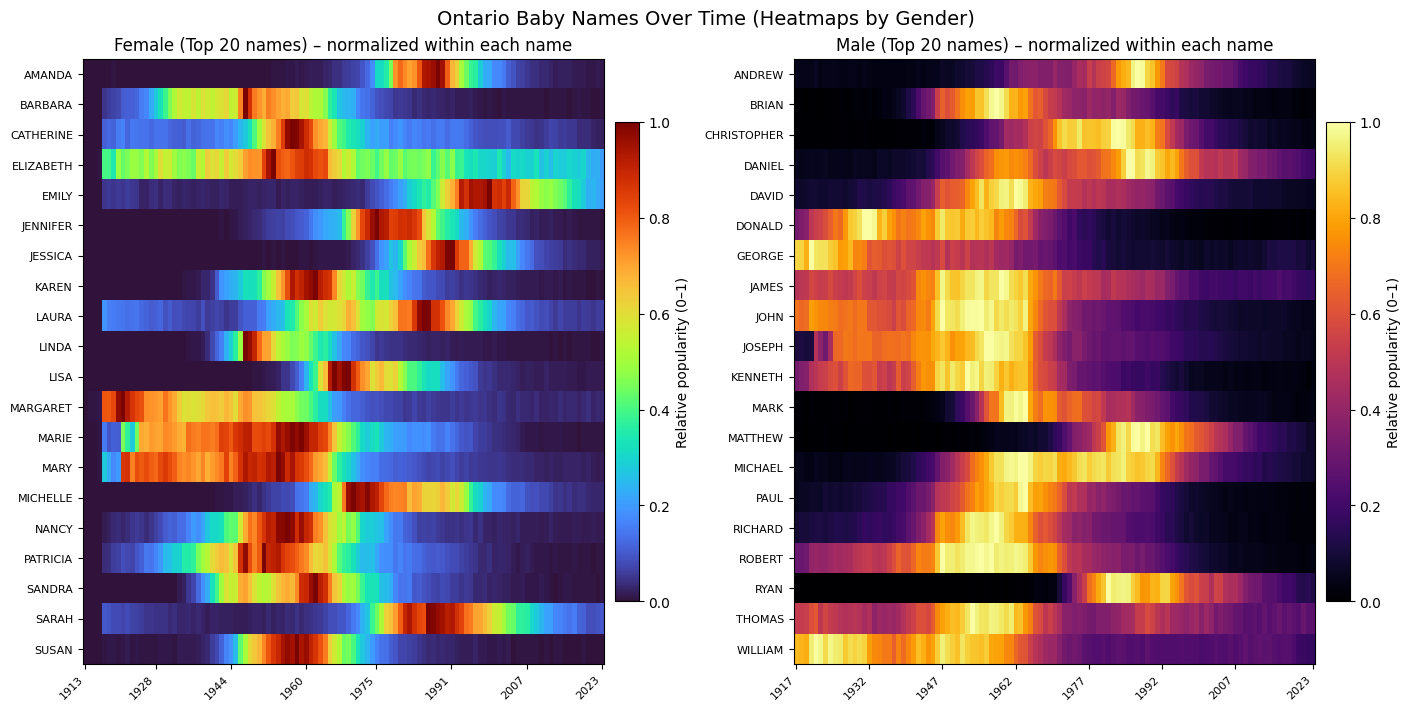

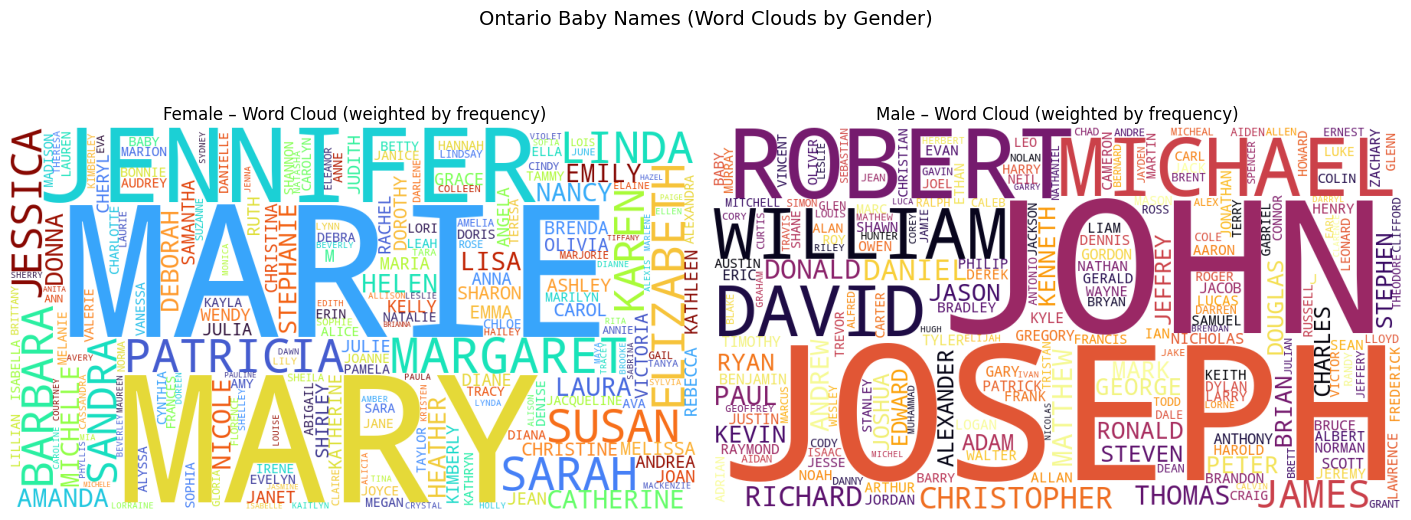

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from wordcloud import WordCloud

female_path = "/Users/lyuxiaotian/Desktop/visualization/02_activities/assignments/ontario_top_baby_names_female.csv"  
male_path   = "/Users/lyuxiaotian/Desktop/visualization/02_activities/assignments/ontario_top_baby_names_male.csv"

df_f = pd.read_csv(female_path)
df_m = pd.read_csv(male_path)

rename_map = {
    "Year/Année": "year",
    "Name/Nom": "name",
    "Frequency/Fréquence": "freq",
    "Year": "year",
    "Name": "name",
    "Frequency": "freq",
}
df_f = df_f.rename(columns=rename_map)
df_m = df_m.rename(columns=rename_map)

df_f["gender"] = "Female"
df_m["gender"] = "Male"

df = pd.concat([df_f, df_m], ignore_index=True)

df["name"] = df["name"].astype(str).str.strip().str.upper()

TOP_N = 20

top_f = (df[df["gender"]=="Female"]
         .groupby("name")["freq"].sum()
         .nlargest(TOP_N).index)

top_m = (df[df["gender"]=="Male"]
         .groupby("name")["freq"].sum()
         .nlargest(TOP_N).index)

df_f_top = df[(df["gender"]=="Female") & (df["name"].isin(top_f))]
df_m_top = df[(df["gender"]=="Male") & (df["name"].isin(top_m))]

pivot_f = df_f_top.pivot_table(index="name", columns="year", values="freq", aggfunc="sum").fillna(0)
pivot_m = df_m_top.pivot_table(index="name", columns="year", values="freq", aggfunc="sum").fillna(0)

def row_normalize(piv):
    arr = piv.to_numpy(dtype=float)
    row_max = arr.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    return pd.DataFrame(arr / row_max, index=piv.index, columns=piv.columns)

pivot_f_n = row_normalize(pivot_f)
pivot_m_n = row_normalize(pivot_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

im1 = axes[0].imshow(pivot_f_n, aspect="auto", interpolation="nearest", cmap="turbo")
axes[0].set_title("Female (Top 20 names) – normalized within each name")
axes[0].set_yticks(np.arange(len(pivot_f_n.index)))
axes[0].set_yticklabels(pivot_f_n.index, fontsize=8)
axes[0].set_xticks(np.linspace(0, len(pivot_f_n.columns)-1, 8).astype(int))
axes[0].set_xticklabels(pivot_f_n.columns[axes[0].get_xticks()], rotation=45, ha="right", fontsize=8)

im2 = axes[1].imshow(pivot_m_n, aspect="auto", interpolation="nearest", cmap="inferno")
axes[1].set_title("Male (Top 20 names) – normalized within each name")
axes[1].set_yticks(np.arange(len(pivot_m_n.index)))
axes[1].set_yticklabels(pivot_m_n.index, fontsize=8)
axes[1].set_xticks(np.linspace(0, len(pivot_m_n.columns)-1, 8).astype(int))
axes[1].set_xticklabels(pivot_m_n.columns[axes[1].get_xticks()], rotation=45, ha="right", fontsize=8)

fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.02, label="Relative popularity (0–1)")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.02, label="Relative popularity (0–1)")

fig.suptitle("Ontario Baby Names Over Time (Heatmaps by Gender)", fontsize=14)
plt.savefig("heatmap_gender.png", dpi=300)
plt.show()

def make_wordcloud(sub_df, colormap):
    freqs = sub_df.groupby("name")["freq"].sum().to_dict()
    wc = WordCloud(width=900, height=500, background_color="white", colormap=colormap)
    return wc.generate_from_frequencies(freqs)

wc_f = make_wordcloud(df[df["gender"]=="Female"], colormap="turbo")
wc_m = make_wordcloud(df[df["gender"]=="Male"], colormap="inferno")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axes[0].imshow(wc_f)
axes[0].axis("off")
axes[0].set_title("Female – Word Cloud (weighted by frequency)")

axes[1].imshow(wc_m)
axes[1].axis("off")
axes[1].set_title("Male – Word Cloud (weighted by frequency)")

fig.suptitle("Ontario Baby Names (Word Clouds by Gender)", fontsize=14)
plt.savefig("wordcloud_gender.png", dpi=300)
plt.show()
